# Loan Default Prediction — Explainable AI

> Upload any loan CSV and this notebook generates all visualisations inline using Python libraries — no image files needed.

---
| Step | Cell | What happens |
|---|---|---|
| 1 | Cell 1 | Install libraries |
| 2 | Cell 2 | **Point to your CSV file** |
| 3 | Cell 3 | **Set your column names** |
| 4 | Cells 4–11 | Everything runs & displays automatically |

In [1]:
# ── CELL 1 — Install libraries ────────────────────────────────────────
import subprocess, sys
pkgs = ['xgboost', 'imbalanced-learn', 'hyperopt', 'shap', 'seaborn']
subprocess.run([sys.executable, '-m', 'pip', 'install'] + pkgs + ['-q'])
print('✓ All libraries installed')

✓ All libraries installed


In [2]:
# ── CELL 2 — Point to your CSV file ──────────────────────────────────
#
#  To switch datasets, change DATA_PATH to your file name:
#
#  Example 1 (sample file 1):  DATA_PATH = '../data/loan_sample_1.csv'
#  Example 2 (sample file 2):  DATA_PATH = '../data/loan_sample_2.csv'
#  Example 3 (your own file):  DATA_PATH = '../data/your_file.csv'
#
# ─────────────────────────────────────────────────────────────────────

DATA_PATH = '../data/loan_sample_1.csv'   # <── CHANGE THIS LINE

# ─────────────────────────────────────────────────────────────────────
import os
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f'File not found: {DATA_PATH}\n'
        f'Available files in data/: {os.listdir("../data/")}'
    )
print(f'✓ Dataset loaded: {DATA_PATH}')

✓ Dataset loaded: ../data/loan_sample_1.csv


In [3]:
# ── CELL 3 — Configure column names to match your CSV ─────────────────
#
#  Edit these values to match YOUR dataset's column names.
#  Run:  print(df.columns.tolist())  to see your column names.
#
CONFIG = {
    # The column that says 1 = defaulted, 0 = did not default
    'target_column':       'Defaulter',

    # Columns to ignore (IDs, dates, etc.)
    'drop_columns':        ['user_id'],

    # Text/category columns (will be label-encoded automatically)
    'categorical_columns': ['loan_category', 'employment_type'],

    # Numeric columns to check for skewness
    'numeric_columns':     ['loan_amount', 'annual_income', 'loan_to_income_ratio'],

    # Pipeline settings (no need to change these)
    'test_size':           0.2,
    'random_state':        42,
    'smote_strategy':      0.5,
    'skew_threshold':      1.0,
}

print('✓ Configuration ready')
print(f'  Target      : {CONFIG["target_column"]}')
print(f'  Drop        : {CONFIG["drop_columns"]}')
print(f'  Categorical : {CONFIG["categorical_columns"]}')

✓ Configuration ready
  Target      : Defaulter
  Drop        : ['user_id']
  Categorical : ['loan_category', 'employment_type']


In [4]:
# ── CELL 4 — Load data & imports ──────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from IPython.display import display
%matplotlib inline

# Global light theme for all plots
mpl.rcParams.update({
    'figure.facecolor': 'white',   'axes.facecolor': '#f8f9fa',
    'axes.edgecolor':   '#dee2e6', 'axes.linewidth': 0.8,
    'axes.grid':        True,      'grid.color':     '#e9ecef',
    'grid.linewidth':   0.6,       'text.color':     '#212529',
    'xtick.color':      '#495057', 'ytick.color':    '#495057',
    'font.family':      'DejaVu Sans', 'font.size':  10,
})

df = pd.read_csv(DATA_PATH)
TARGET = CONFIG['target_column']

print('=' * 52)
print('  DATASET OVERVIEW')
print('=' * 52)
print(f'  File        : {os.path.basename(DATA_PATH)}')
print(f'  Rows        : {df.shape[0]:,}')
print(f'  Columns     : {df.shape[1]}')
print(f'  Duplicates  : {df.duplicated().sum()}')
missing = df.isnull().sum()
missing = missing[missing > 0]
if not missing.empty:
    print('  Missing values:')
    for col, cnt in missing.items():
        print(f'    {col:<28} {cnt} ({cnt/len(df):.1%})')
if TARGET in df.columns:
    vc = df[TARGET].value_counts()
    print(f'  Default rate: {vc.get(1,0)/len(df):.1%}')
print('=' * 52)
print()
display(df.head(5))
print()
display(df.describe().T.round(2))

  DATASET OVERVIEW
  File        : loan_sample_1.csv
  Rows        : 3,000
  Columns     : 14
  Duplicates  : 0
  Missing values:
    employment_type              124 (4.1%)
    annual_income                115 (3.8%)
    credit_score                 127 (4.2%)
    monthly_obligations          123 (4.1%)
  Default rate: 14.2%



,customer_id,loan_category,loan_amount,interest_rate,tenure_months,employment_type,annual_income,credit_score,existing_loans,age,monthly_obligations,emi_to_income_ratio,loan_to_income_ratio,Defaulter
0,CUST_000001,Vehicle,213000,12.44,36,Private Sector,200000.00,568.0,2,38,1442.0,0.3550,1.065,0
1,CUST_000002,Business Expansion,248000,9.86,240,Government,200000.00,712.0,1,21,24849.0,0.0620,1.240,0
2,CUST_000003,Education Loan,484000,9.86,18,Government,200000.00,537.0,0,38,2053.0,1.6133,2.420,0
3,CUST_000004,Credit Card,917000,10.91,12,Unemployed,200000.00,800.0,0,36,8463.0,4.5850,4.585,0
4,CUST_000005,Mortgage,595000,9.98,12,Private Sector,222926.02,607.0,1,25,8975.0,2.6690,2.669,0


,count,mean,std,min,25%,50%,75%,max
loan_amount,3000.0,561691.67,339946.07,60000.00,294750.00,535000.00,795000.00,3913000.00
interest_rate,3000.0,10.58,3.40,4.00,8.15,10.54,12.93,22.13
tenure_months,3000.0,77.74,73.52,6.00,18.00,60.00,120.00,240.00
annual_income,2885.0,216575.54,58262.26,200000.00,200000.00,200000.00,200000.00,934219.59
credit_score,2873.0,668.70,83.53,332.00,611.00,670.00,725.00,900.00
existing_loans,3000.0,0.91,0.95,0.00,0.00,1.00,1.00,6.00
age,3000.0,37.59,9.66,21.00,30.00,37.00,44.00,70.00
monthly_obligations,2877.0,12770.84,7101.89,502.00,6667.00,12713.00,18968.00,24998.00
emi_to_income_ratio,3000.0,1.31,1.85,0.02,0.22,0.55,1.59,9.98
loan_to_income_ratio,3000.0,2.60,1.36,0.30,1.42,2.54,3.78,5.00


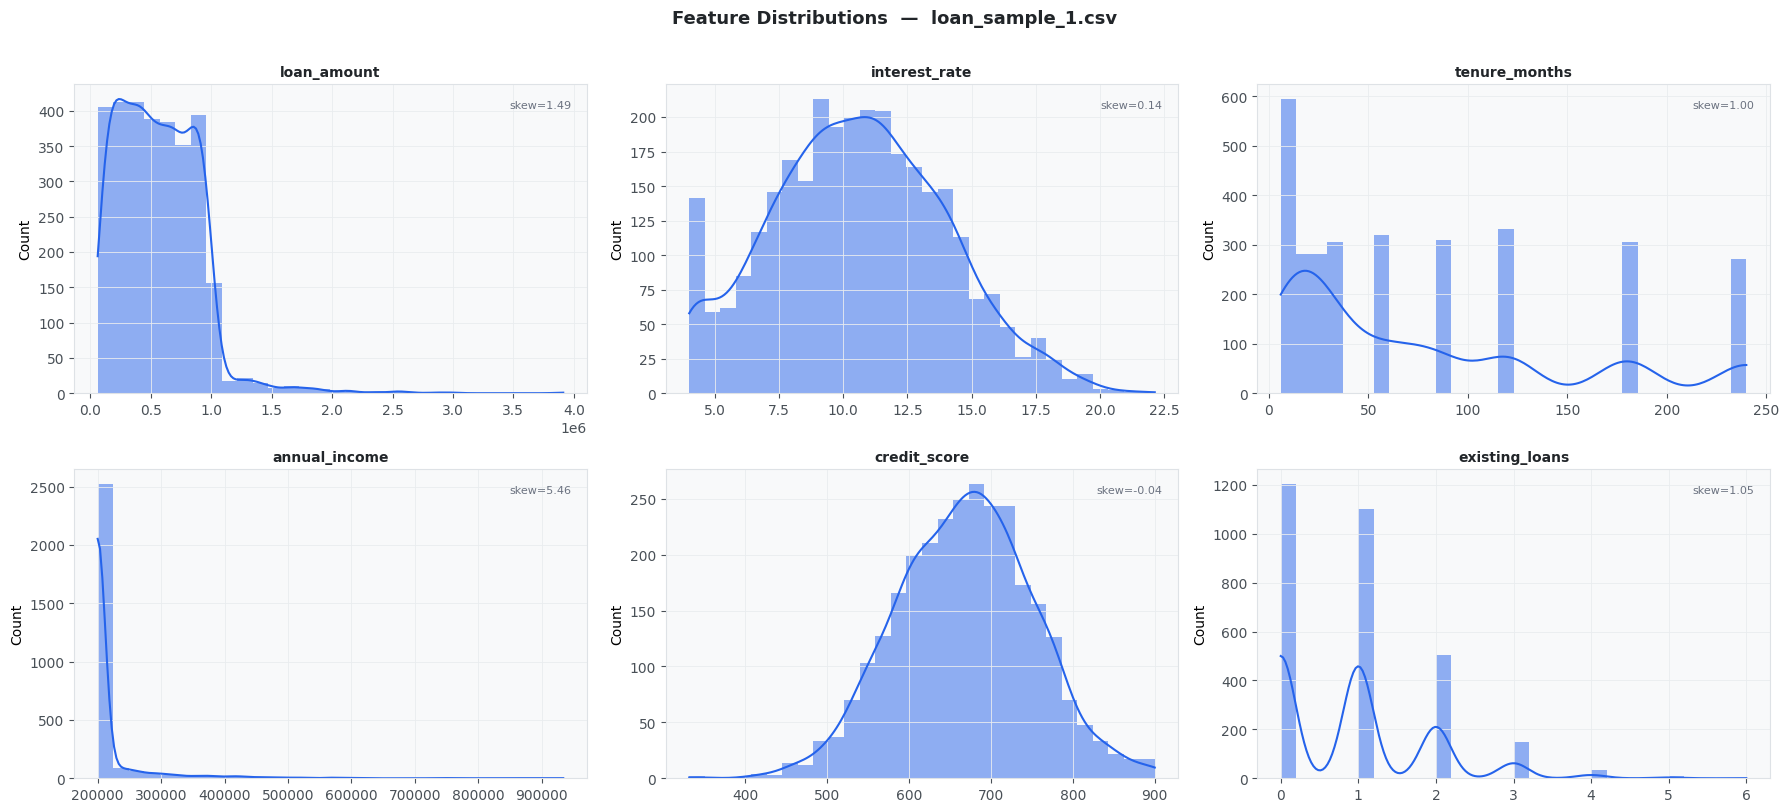

In [5]:
# ── CELL 5 — EDA: Feature distributions ──────────────────────────────
num_cols = (df.select_dtypes(include='number')
              .drop(columns=[TARGET], errors='ignore')
              .columns.tolist()[:6])

n = len(num_cols)
cols_per_row = min(3, n)
rows = (n + cols_per_row - 1) // cols_per_row

fig, axes = plt.subplots(rows, cols_per_row,
                         figsize=(6 * cols_per_row, 4 * rows))
axes = np.array(axes).flatten() if n > 1 else [axes]

for ax, col in zip(axes, num_cols):
    sns.histplot(df[col].dropna(), ax=ax, color='#2563eb',
                 kde=True, bins=30, edgecolor='none')
    ax.set_title(col, fontsize=10, fontweight='semibold')
    ax.set_xlabel('')
    skew = df[col].skew()
    ax.text(0.97, 0.95, f'skew={skew:.2f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='#6b7280')

for ax in axes[n:]:
    ax.set_visible(False)

plt.suptitle(f'Feature Distributions  —  {os.path.basename(DATA_PATH)}',
             fontsize=13, fontweight='semibold', y=1.01)
plt.tight_layout()
plt.show()

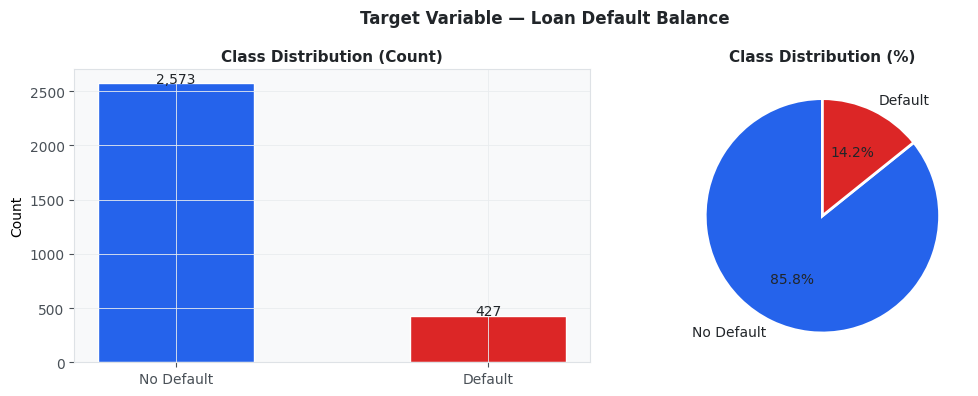

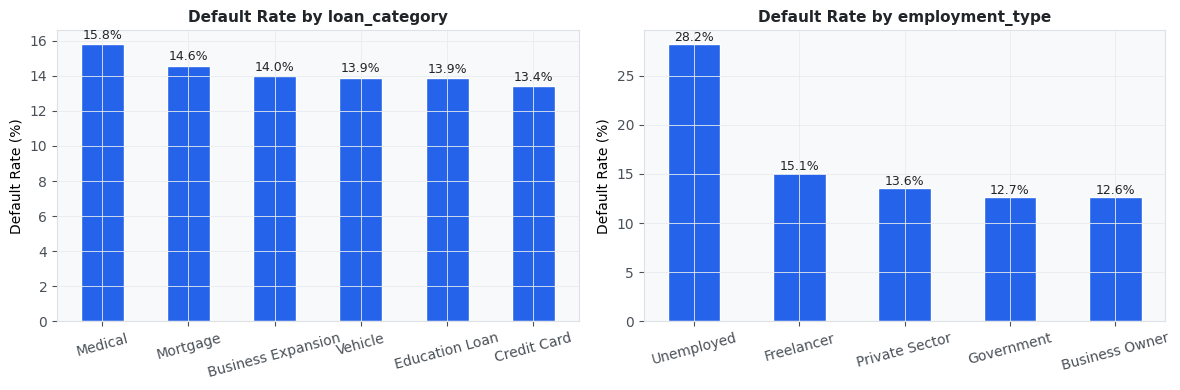

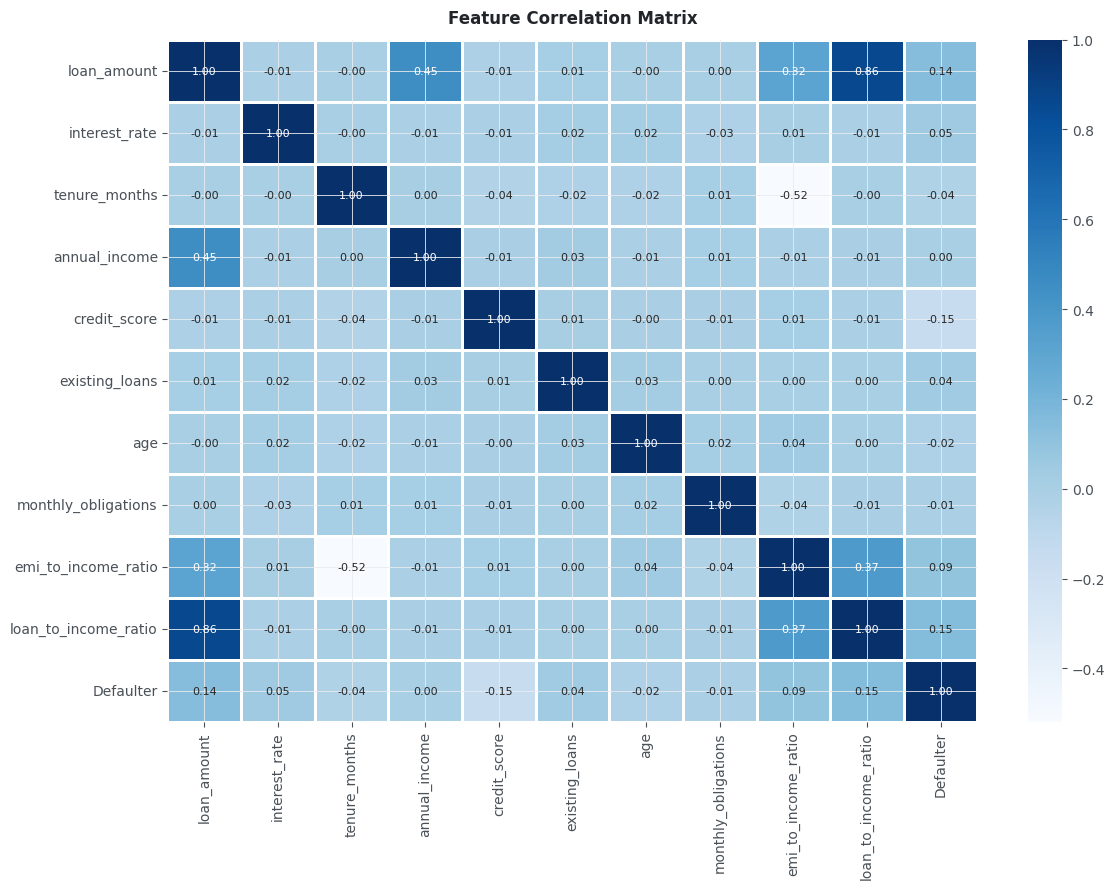

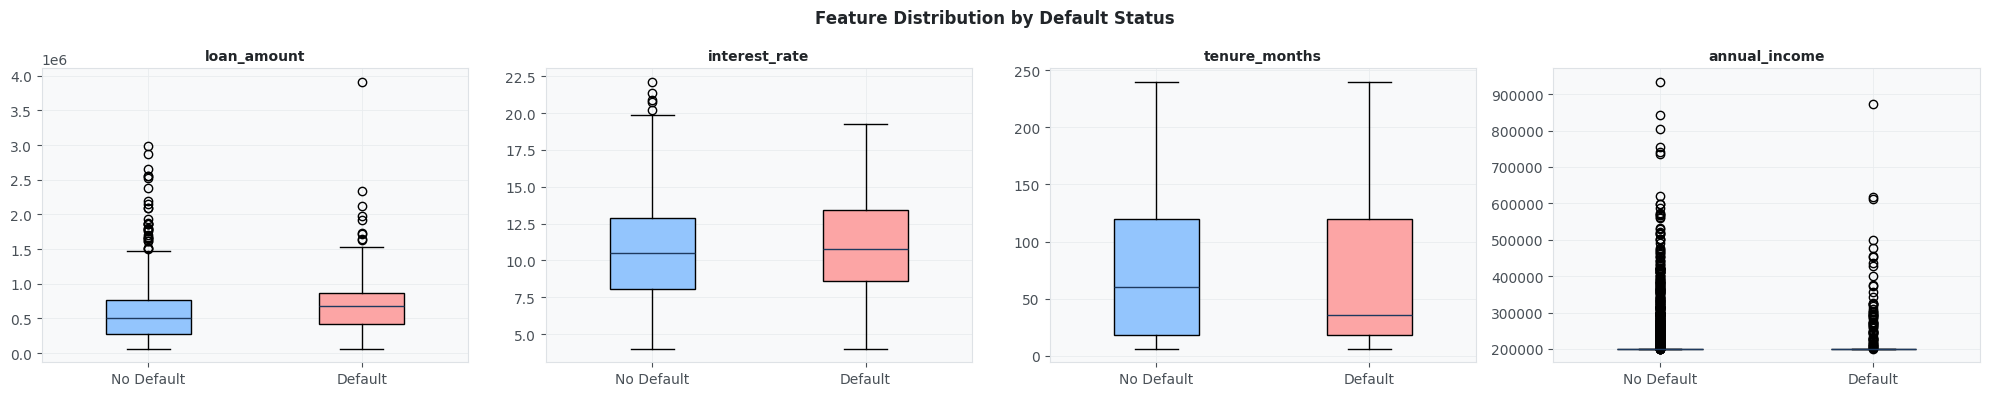

In [6]:
# ── CELL 6 — EDA: Class balance, default rates, correlation, boxplots ─

# ── Plot A: Class balance ─────────────────────────────────────────────
if TARGET in df.columns:
    vc = df[TARGET].value_counts()
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    colors = ['#2563eb', '#dc2626']
    axes[0].bar(['No Default', 'Default'], vc.values,
                color=colors, edgecolor='white', width=0.5)
    axes[0].set_title('Class Distribution (Count)',
                      fontweight='semibold', fontsize=11)
    axes[0].set_ylabel('Count')
    for i, v in enumerate(vc.values):
        axes[0].text(i, v + 5, f'{v:,}', ha='center', fontsize=10)
    axes[1].pie(vc.values, labels=['No Default', 'Default'],
                colors=colors, autopct='%1.1f%%', startangle=90,
                wedgeprops={'edgecolor': 'white', 'linewidth': 2})
    axes[1].set_title('Class Distribution (%)',
                      fontweight='semibold', fontsize=11)
    plt.suptitle('Target Variable — Loan Default Balance',
                 fontsize=12, fontweight='semibold')
    plt.tight_layout()
    plt.show()

# ── Plot B: Default rate by categorical columns ───────────────────────
cat_cols = [c for c in CONFIG['categorical_columns'] if c in df.columns]
if cat_cols and TARGET in df.columns:
    fig, axes = plt.subplots(1, len(cat_cols),
                             figsize=(6 * len(cat_cols), 4))
    if len(cat_cols) == 1: axes = [axes]
    for ax, col in zip(axes, cat_cols):
        rate = (df.groupby(col)[TARGET].mean().sort_values(ascending=False) * 100)
        bars = ax.bar(rate.index, rate.values,
                      color='#2563eb', edgecolor='white', width=0.5)
        ax.set_title(f'Default Rate by {col}',
                     fontweight='semibold', fontsize=11)
        ax.set_ylabel('Default Rate (%)')
        ax.tick_params(axis='x', rotation=15)
        for bar, val in zip(bars, rate.values):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.3,
                    f'{val:.1f}%', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

# ── Plot C: Correlation heatmap ───────────────────────────────────────
num_df = df.select_dtypes(include='number')
if num_df.shape[1] >= 2:
    fig, ax = plt.subplots(figsize=(min(12, num_df.shape[1] + 2),
                                    min(9,  num_df.shape[1])))
    sns.heatmap(num_df.corr(), annot=True, fmt='.2f',
                cmap='Blues', linewidths=1, linecolor='white',
                annot_kws={'size': 8}, ax=ax)
    ax.set_title('Feature Correlation Matrix',
                 fontsize=12, fontweight='semibold', pad=12)
    plt.tight_layout()
    plt.show()

# ── Plot D: Boxplots by target ────────────────────────────────────────
if TARGET in df.columns and num_cols:
    top4 = num_cols[:4]
    fig, axes = plt.subplots(1, len(top4), figsize=(5 * len(top4), 4))
    if len(top4) == 1: axes = [axes]
    for ax, col in zip(axes, top4):
        groups = [df[df[TARGET]==0][col].dropna(),
                  df[df[TARGET]==1][col].dropna()]
        bp = ax.boxplot(groups, labels=['No Default','Default'],
                        patch_artist=True, widths=0.4)
        bp['boxes'][0].set_facecolor('#93c5fd')
        bp['boxes'][1].set_facecolor('#fca5a5')
        for m in bp['medians']: m.set_color('#1e3a5f')
        ax.set_title(col, fontsize=10, fontweight='semibold')
    plt.suptitle('Feature Distribution by Default Status',
                 fontsize=12, fontweight='semibold')
    plt.tight_layout()
    plt.show()

In [7]:
# ── CELL 7 — Preprocessing ────────────────────────────────────────────
from src.data_preparation.preprocessor import LoanPreprocessor

preprocessor = LoanPreprocessor(
    target_col=CONFIG['target_column'],
    drop_cols=CONFIG['drop_columns'],
    categorical_cols=CONFIG['categorical_columns'],
    numeric_cols=CONFIG['numeric_columns'],
    skew_threshold=CONFIG['skew_threshold'],
    test_size=CONFIG['test_size'],
    random_state=CONFIG['random_state'],
    smote_strategy=CONFIG['smote_strategy'],
)
X_train, X_test, y_train, y_test, feature_names = preprocessor.fit_transform(df)
print(f'\n✓ Features ({len(feature_names)}): {feature_names}')

[Preprocessor] Log-transform 'loan_amount'  (skew=1.49)
[Preprocessor] Log-transform 'annual_income'  (skew=5.58)
[Preprocessor] ⚠  High multicollinearity detected:
   loan_to_income_ratio  ↔  loan_amount  (r=0.92)
[Preprocessor] Auto-dropping non-numeric columns: ['customer_id']
[Preprocessor] Train: (3087, 12)  |  Test: (600, 12)
[Preprocessor] Train class balance after SMOTE: [2058 1029]

✓ Features (12): ['loan_category', 'loan_amount', 'interest_rate', 'tenure_months', 'employment_type', 'annual_income', 'credit_score', 'existing_loans', 'age', 'monthly_obligations', 'emi_to_income_ratio', 'loan_to_income_ratio']


In [ ]:
# ── CELL 8 — Train XGBoost + Random Forest ───────────────────────────
import yaml
from src.models.xgboost_model import XGBoostModel
from src.models.random_forest_model import RandomForestModel

with open('../config/config.yaml') as f:
    cfg = yaml.safe_load(f)

# XGBoost
xgb = XGBoostModel(cfg['xgboost'])
xgb.tune(X_train, y_train, max_evals=20)
xgb.fit(X_train, y_train, use_tuned=True)
print('✓ XGBoost trained\n')

# Random Forest
cfg['random_forest']['grid_search']['param_grid'] = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}
rf = RandomForestModel(cfg['random_forest'])
rf.tune(X_train, y_train)
rf.fit(X_train, y_train, use_tuned=True)
print('\n✓ Random Forest trained')

[XGBoost] Running Hyperopt (20 evaluations)...


In [ ]:
# ── CELL 9 — Evaluation plots (inline) ───────────────────────────────
from src.evaluation.metrics import evaluate, plot_confusion_matrix, plot_roc_curve
from src.models.tuning import compare_models, threshold_analysis

all_results = {}
for name, model in [('XGBoost', xgb), ('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    metrics = evaluate(y_true=y_test, y_pred=y_pred,
                       y_prob=y_prob, model_name=name)
    all_results[name] = metrics
    # Pass save_dir=None → display inline only, no file saved
    plot_confusion_matrix(y_test, y_pred, model_name=name, save_dir=None)
    plot_roc_curve(y_test, y_prob, model_name=name, save_dir=None)

compare_models(all_results, save_dir=None)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
threshold_analysis(y_test, y_prob_xgb, model_name='XGBoost', save_dir=None)

In [ ]:
# ── CELL 10 — SHAP Explainability (inline) ───────────────────────────
from src.explainability.shap_explainer import SHAPExplainer

shap_exp = SHAPExplainer(
    model=xgb.model,
    X_background=X_train,
    feature_names=feature_names,
    background_samples=100,
)
shap_values = shap_exp.compute_shap_values(X_test)

# Global feature importance — pass save_dir=None → inline only
shap_exp.plot_summary(X_test, shap_values, save_dir=None)
shap_exp.plot_bar_importance(shap_values, save_dir=None)

# Auto-pick top 3 most important features for dependence plots
mean_abs = np.abs(shap_values).mean(axis=0)
top3 = [feature_names[i] for i in np.argsort(mean_abs)[::-1][:3]]
print(f'Top 3 features: {top3}')
for feat in top3:
    shap_exp.plot_dependence(X_test, shap_values,
                             feature=feat, save_dir=None)

# Single applicant waterfall explanation
shap_exp.plot_waterfall(X_test, sample_index=5, save_dir=None)
shap_exp.explain_prediction_text(X_test, shap_values, sample_index=5)

In [ ]:
# ── CELL 11 — Anchors & Counterfactuals ──────────────────────────────
from src.explainability.anchors_explainer import AnchorsExplainer
from src.explainability.counterfactuals import CounterfactualExplainer

# Anchor IF-THEN rules
anchor_exp = AnchorsExplainer(
    model=xgb.model,
    feature_names=feature_names,
    threshold=0.95,
)
anchor_exp.fit(X_train)
anchor_exp.explain(X_test, sample_index=5)

# Counterfactuals — what would flip this decision?
cf_exp = CounterfactualExplainer(
    model=xgb.model,
    feature_names=feature_names,
    X_train=X_train,
    y_train=y_train,
    num_cfs=3,
    desired_class=0,
)
cf_exp.explain(X_test, sample_index=5)